<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Лабораторная работа №7**

Тема: Анализ и прогнозирование временного ряда.
Цель: изучение основных методов анализа и прогнозирования временных рядов.

В работе используется датасет supermarket_sales.csv. На его основе формируется временной ряд по годам для выбранного вида сельскохозяйственной продукции. Далее строятся прогнозы методами ARIMA, символьной регрессии

In [ ]:
!pip install gplearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 57.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA
from gplearn.genetic import SymbolicRegressor

plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/supermarket_sales.csv"
df = pd.read_csv("/content/drive/MyDrive/supermarket_sales.csv")

df.head()

Mounted at /content/drive


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
print('Наиболее часто встречающиеся виды продукции:')
print(df['Product line'].value_counts().head(20))
product_name = df['Product line'].value_counts().idxmax()
print('\nВыбранный вид продукции:', product_name)

Наиболее часто встречающиеся виды продукции:
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

Выбранный вид продукции: Fashion accessories


In [ ]:
df['Date'] = pd.to_datetime(df['Date']).dt.day

In [ ]:
ts_df = df[df['Product line'] == product_name].copy()

ts_df = (
    ts_df
    .groupby('Date', as_index=False)['Unit price']
    .mean()
    .sort_values('Date')
)

ts_df = ts_df.dropna().reset_index(drop=True)

print('\nСформированный временной ряд:')
print(ts_df)


Сформированный временной ряд:
    Date  Unit price
0      1   61.980000
1      2   63.425000
2      3   59.070000
3      4   59.585000
4      5   50.813333
5      6   57.126000
6      7   59.391429
7      8   51.036000
8      9   58.223333
9     10   61.740000
10    11   82.160000
11    12   55.980000
12    13   46.765556
13    14   51.246667
14    15   60.702857
15    16   67.665714
16    17   40.285000
17    18   69.768571
18    19   66.255000
19    20   56.674000
20    21   43.180000
21    22   35.372000
22    23   48.345000
23    24   80.605000
24    25   64.835000
25    26   50.207273
26    27   54.252857
27    28   51.988000
28    29   52.646667
29    30   10.180000
30    31   70.325000


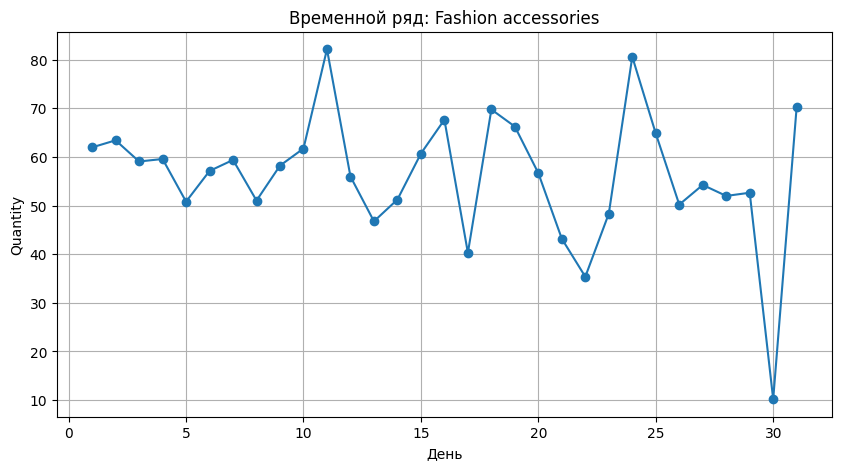

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ts_df['Date'], ts_df['Unit price'], marker='o')
plt.title(f'Временной ряд: {product_name}')
plt.xlabel('День')
plt.ylabel('Quantity')
plt.grid(True)
plt.show()

In [ ]:
print('Основные характеристики временного ряда:')
print(ts_df['Unit price'].describe())

print('\nКоличество наблюдений:', len(ts_df))
print('Минимальный день:', ts_df['Date'].min())
print('Максимальный день:', ts_df['Date'].max())

ts_df['Изменение'] = ts_df['Unit price'].diff()
ts_df['Темп_изменения_%'] = ts_df['Unit price'].pct_change() * 100

print('\nРяд с изменениями по дням:')
print(ts_df)

Основные характеристики временного ряда:
count    31.000000
mean     56.188073
std      13.425605
min      10.180000
25%      50.924667
50%      57.126000
75%      62.702500
max      82.160000
Name: Unit price, dtype: float64

Количество наблюдений: 31
Минимальный день: 1
Максимальный день: 31

Ряд с изменениями по дням:
    Date  Unit price  Изменение  Темп_изменения_%
0      1   61.980000        NaN               NaN
1      2   63.425000   1.445000          2.331397
2      3   59.070000  -4.355000         -6.866378
3      4   59.585000   0.515000          0.871847
4      5   50.813333  -8.771667        -14.721267
5      6   57.126000   6.312667         12.423248
6      7   59.391429   2.265429          3.965670
7      8   51.036000  -8.355429        -14.068408
8      9   58.223333   7.187333         14.082870
9     10   61.740000   3.516667          6.039961
10    11   82.160000  20.420000         33.074182
11    12   55.980000 -26.180000        -31.864654
12    13   46.765556  -9.21

Обучающая выборка:
    Date  Unit price  Изменение  Темп_изменения_%
0      1   61.980000        NaN               NaN
1      2   63.425000   1.445000          2.331397
2      3   59.070000  -4.355000         -6.866378
3      4   59.585000   0.515000          0.871847
4      5   50.813333  -8.771667        -14.721267
5      6   57.126000   6.312667         12.423248
6      7   59.391429   2.265429          3.965670
7      8   51.036000  -8.355429        -14.068408
8      9   58.223333   7.187333         14.082870
9     10   61.740000   3.516667          6.039961
10    11   82.160000  20.420000         33.074182
11    12   55.980000 -26.180000        -31.864654
12    13   46.765556  -9.214444        -16.460244
13    14   51.246667   4.481111          9.582076
14    15   60.702857   9.456190         18.452304
15    16   67.665714   6.962857         11.470394
16    17   40.285000 -27.380714        -40.464679
17    18   69.768571  29.483571         73.187468
18    19   66.255000  -3.513571

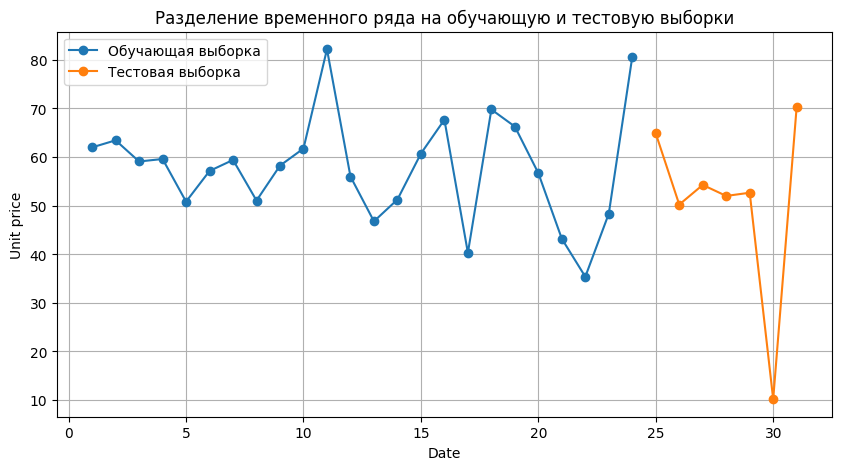

In [ ]:
train_size = int(len(ts_df) * 0.8)

train = ts_df.iloc[:train_size].copy()
test = ts_df.iloc[train_size:].copy()

print('Обучающая выборка:')
print(train)

print('\nТестовая выборка:')
print(test)

plt.figure(figsize=(10, 5))
plt.plot(train['Date'], train['Unit price'], marker='o', label='Обучающая выборка')
plt.plot(test['Date'], test['Unit price'], marker='o', label='Тестовая выборка')
plt.title('Разделение временного ряда на обучающую и тестовую выборки')
plt.xlabel('Date')
plt.ylabel('Unit price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
arima_model = ARIMA(train['Unit price'], order=(1, 1, 1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))
test['ARIMA_forecast'] = arima_forecast.values

print(test[['Date', 'Unit price', 'ARIMA_forecast']])

    Date  Unit price  ARIMA_forecast
24    25   64.835000       61.279389
25    26   50.207273       58.472852
26    27   54.252857       58.065276
27    28   51.988000       58.006086
28    29   52.646667       57.997490
29    30   10.180000       57.996242
30    31   70.325000       57.996061


In [ ]:
X_train_sr = train[['Date']]
y_train_sr = train['Unit price']

X_test_sr = test[['Date']]
y_test_sr = test['Unit price']

symbolic_model = SymbolicRegressor(
    population_size=1000,
    generations=20,
    stopping_criteria=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=42
)

symbolic_model.fit(X_train_sr, y_train_sr)

symbolic_forecast = symbolic_model.predict(X_test_sr)
test['Symbolic_forecast'] = symbolic_forecast

print('Полученная формула символьной регрессии:')
print(symbolic_model._program)

print('\nПрогноз:')
print(test[['Date', 'Unit price', 'Symbolic_forecast']])

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    48.87      2.83426e+10      127          12.7268          21.2236     23.50s
   1    30.78          360.123      125          9.62529          10.4518     17.25s
   2    65.38          5440.91      125          8.20454          20.3971     20.45s
   3   124.50          1294.88      155          7.60695          24.6174     46.42s
   4   127.97          1995.61      155          7.50401          19.2276      1.31m
   5   135.18          679.042      105          7.21579          23.5992     58.94s
   6   132.96          285.305       99          7.23263          23.3675     23.50s
   7   141.75          3347.33      117          7.16339           19.764     21.12s
   8   142.18          623.401      323          6.83869          23.7868  

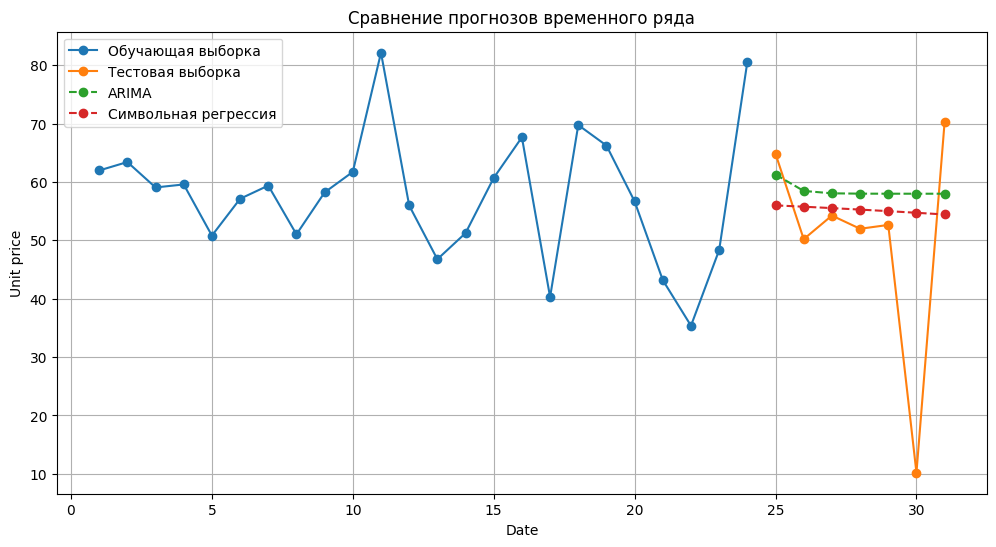

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(train['Date'], train['Unit price'], marker='o', label='Обучающая выборка')
plt.plot(test['Date'], test['Unit price'], marker='o', label='Тестовая выборка')

plt.plot(test['Date'], test['ARIMA_forecast'], marker='o', linestyle='--', label='ARIMA')
plt.plot(test['Date'], test['Symbolic_forecast'], marker='o', linestyle='--', label='Символьная регрессия')

plt.title('Сравнение прогнозов временного ряда')
plt.xlabel('Date')
plt.ylabel('Unit price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

metrics = []

mae, rmse = calculate_metrics(test['Unit price'], test['ARIMA_forecast'])
metrics.append(['ARIMA', mae, rmse])

mae, rmse = calculate_metrics(test['Unit price'], test['Symbolic_forecast'])
metrics.append(['Символьная регрессия', mae, rmse])

metrics_df = pd.DataFrame(metrics, columns=['Метод', 'MAE', 'RMSE'])
metrics_df = metrics_df.sort_values(by='MAE').reset_index(drop=True)

print('Итоговая таблица качества прогнозов:')
print(metrics_df)

Итоговая таблица качества прогнозов:
                  Метод        MAE       RMSE
0  Символьная регрессия  11.681055  18.377855
1                 ARIMA  12.449671  19.267816


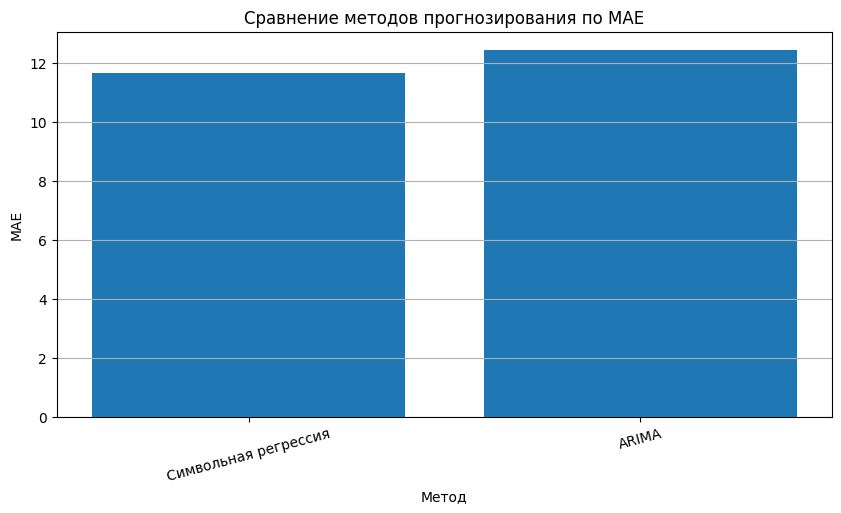

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(metrics_df['Метод'], metrics_df['MAE'])
plt.title('Сравнение методов прогнозирования по MAE')
plt.xlabel('Метод')
plt.ylabel('MAE')
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

In [ ]:
!pip install gmdhpy

In [ ]:
from gmdhpy import gmdh

In [ ]:
# Подготовка данных для gmdh
X_train_gmdh = train[['Date']].values
y_train_gmdh = train['Unit price'].values
X_test_gmdh = test[['Date']].values

gmdh_available = False

try:
    from gmdhpy import Combi, Mia
    gmdh_available = True
    print('Библиотека gmdh успешно импортирована.')
except Exception as e:
    print('Не удалось импортировать библиотеку gmdh.')
    print('Текст ошибки:')
    print(e)

Не удалось импортировать библиотеку gmdh.
Текст ошибки:
cannot import name 'Combi' from 'gmdhpy' (/usr/local/lib/python3.12/dist-packages/gmdhpy/__init__.py)
